# **Balanced: XGBoost**

# **Cybersecurity Network Traffic Dataset: Baseline**

This dataset contains **network traffic records used for cybersecurity analysis**, specifically focused on detecting **Distributed Denial of Service (DDoS) and network flooding attacks**.  
Each CSV file represents traffic captured during a **specific attack type or normal network behavior**.


The dataset is divided into multiple CSV files, each corresponding to a specific attack category or normal traffic type.

| File | Description |
|-----|-------------|
| `DrDoS_DNS.csv` | DNS amplification Distributed Reflection Denial of Service attack traffic |
| `DrDoS_LDAP.csv` | LDAP reflection DDoS attack traffic |
| `DrDoS_MSSQL.csv` | MSSQL reflection DDoS attack traffic |
| `DrDoS_NetBIOS.csv` | NetBIOS reflection DDoS attack traffic |
| `DrDoS_NTP.csv` | NTP amplification attack traffic |
| `DrDoS_SNMP.csv` | SNMP reflection DDoS attack traffic |
| `DrDoS_SSDP.csv` | SSDP reflection DDoS attack traffic |
| `DrDoS_UDP.csv` | UDP flood distributed denial of service traffic |
| `Syn.csv` | SYN flood attack traffic |

These attack types are examples of volumetric or reflection-based DDoS attacks, where attackers overwhelm a server or network by generating massive traffic.

For training, we only consider the following CSV files due to limited computational resources. These CSV files were selected because these traffic types are commonly associated with reflection and amplification attacks. In these attacks, the attacker sends spoofed requests to legitimate servers (such as DNS, LDAP, or NTP services). The source IP address is forged to appear as the victim's address. As a result, the legitimate server sends the response to the victim instead of the attacker. Therefore, the analysis will focus on the following datasets:

- **DNS.csv**
- **LDAP.csv**
- **NTP.csv**
- **Syn.csv**



### **00 Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
import seaborn as sns
import time
import json
import os
import optuna
from optuna.visualization.matplotlib import plot_pareto_front

In [2]:
def confusion_matrix_heatmap(
    y_true,
    y_pred,
    save_dir,
    model_name="Model",
    normalize=False,
    figsize=(7, 6),
    dpi=600
):
    """
    Generates and saves a publication-quality confusion matrix heatmap.

    Parameters:
    - y_true : array-like
        Ground truth labels.
    - y_pred : array-like
        Predicted labels.
    - model_name : str
        Name used for plot title and export filename.
    - normalize : bool
        If True, displays normalized percentages.
    - figsize : tuple
        Figure size.

    dpi : int
        Export image quality.
    """

    save_dir = os.path.join("results", "plots")
    os.makedirs(save_dir, exist_ok=True)

    cm = confusion_matrix(y_true, y_pred)

    if normalize:
        cm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]
        fmt = ".2f"
    else:
        fmt = "d"

    # Labels
    labels = ["No Attack", "Attack"]
    plt.style.use("seaborn-v0_8-white")
    fig, ax = plt.subplots(figsize=figsize, dpi=dpi)

    sns.heatmap(
        cm,
        annot=True,
        fmt=fmt,
        cmap="Blues",
        cbar=True,
        square=True,
        linewidths=1,
        linecolor="black",
        xticklabels=labels,
        yticklabels=labels,
        annot_kws={
            "size": 13,
            "weight": "bold"
        },
        ax=ax
    )

    # Titles and labels
    ax.set_title(
        f"{model_name} Confusion Matrix",
        fontsize=16,
        weight="bold",
        pad=15
    )

    ax.set_xlabel(
        "Predicted Label",
        fontsize=13,
        weight="bold"
    )

    ax.set_ylabel(
        "True Label",
        fontsize=13,
        weight="bold"
    )

    # Tick formatting
    ax.tick_params(axis='both', labelsize=11)

    plt.xticks(rotation=0)
    plt.yticks(rotation=0)

    # Improve spacing
    plt.tight_layout()

    # Export paths
    png_path = os.path.join(
        save_dir,
        f"{model_name.lower().replace(' ', '_')}_confusion_matrix.png"
    )

    pdf_path = os.path.join(
        save_dir,
        f"{model_name.lower().replace(' ', '_')}_confusion_matrix.pdf"
    )

    # Save figures
    plt.savefig(png_path, dpi=dpi, bbox_inches="tight")    
    plt.savefig(pdf_path, bbox_inches="tight")
        
    print(f"Confusion matrix saved to:")
    print(f" - {png_path}")
    print(f" - {pdf_path}")

    plt.show()

### **01 Load Dataset**

The preprocessed dataset generated in the `02_Preprocessed.ipynb` notebook was loaded for the training phase.

After loading the dataset:

1. The target variable (`Label`) was separated from the feature set.
2. The label column was removed from the input features to avoid data leakage during training.
3. Feature scaling was applied using `StandardScaler`.

Standardization was performed to normalize the feature distributions and improve neural network convergence during training.

This preprocessing step ensures that all numerical features contribute proportionally during optimization and model training.

In [3]:
path = r"C:\\Users\\Ale\\Documents\\NN-Labs\\Midterm\\Optuna-MLP-DDoS-detection\\Data_Preprocessing\\preprocessed_data"
train_path = f"{path}/train.csv"
val_path = f"{path}/val.csv"
test_path = f"{path}/test.csv"

In [4]:
train = pd.read_csv(train_path)
val = pd.read_csv(val_path)
test = pd.read_csv(test_path)

In [5]:
# Train
X_train = train.drop(["Label"], axis=1)
y_train = train["Label"]

# Validation
X_val = val.drop(["Label"], axis=1)
y_val = val["Label"]

# Test
X_test = test.drop(["Label"], axis=1)
y_test = test["Label"]

In [6]:
X_train = X_train.astype('float32')
X_val   = X_val.astype('float32')
X_test  = X_test.astype('float32')

In [7]:
print(X_train.shape)
print(X_train.dtypes)
print(X_train.info())

(25059, 63)
Unnamed: 0          float32
Source Port         float32
Destination Port    float32
Protocol            float32
Flow Duration       float32
                     ...   
Idle Mean           float32
Idle Std            float32
Idle Max            float32
Idle Min            float32
Inbound             float32
Length: 63, dtype: object
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25059 entries, 0 to 25058
Data columns (total 63 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Unnamed: 0                   25059 non-null  float32
 1   Source Port                  25059 non-null  float32
 2   Destination Port             25059 non-null  float32
 3   Protocol                     25059 non-null  float32
 4   Flow Duration                25059 non-null  float32
 5   Total Fwd Packets            25059 non-null  float32
 6   Total Backward Packets       25059 non-null  float32
 7   Total Length of Fw

In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

# **1. Baseline Model**

A baseline XGBoost model was defined in order to establish a reference point for comparison with the Optuna multi-objective optimization process.

This baseline configuration was intentionally designed using a fixed set of hyperparameters. The objective is to evaluate how much performance improvement can be achieved after hyperparameter optimization.

The baseline model consists of:

- An XGBoost classifier configured with:
  - 100 boosting trees (`n_estimators=100`)
  - A learning rate of 0.1
  - A maximum tree depth of 6
  - Default regularization parameters
  - Binary logistic objective function

The binary logistic objective was selected because the problem is formulated as a binary classification task, where the model predicts whether the network traffic corresponds to normal behavior or an attack.

XGBoost was selected due to its strong performance in tabular classification problems and its ability to capture complex nonlinear relationships through gradient-boosted decision trees.

The baseline configuration serves as the reference model against which the optimized Optuna-generated configurations are compared in terms of:

- F1-score
- Prediction time
- Overall classification performance change

The optimization process explores different XGBoost hyperparameter combinations to identify Pareto-optimal solutions that maximize classification performance while minimizing inference latency.






In [13]:
from xgboost import XGBClassifier

In [12]:
#import sys
#!{sys.executable} -m pip install xgboost 

In [ ]:
def create_baseline_model(random_state=42):

    model = XGBClassifier(
        n_estimators=100,
        max_depth=4,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        n_jobs=-1,
        random_state=random_state
    )

    return model

## **Baseline Architecture**

| Component              | Configuration |
|------------------------|---------------|
| Model Type             | XGBoost Classifier |
| Number of Trees        | 100 (`n_estimators=100`) |
| Maximum Depth          | 4 (`max_depth=4`) |
| Learning Rate          | 0.1 (`learning_rate=0.1`) |
| Subsample Ratio        | 0.8 (`subsample=0.8`) |
| Feature Sampling Ratio | 0.8 (`colsample_bytree=0.8`) |
| Objective Function     | Binary Logistic (`objective='binary:logistic'`) |
| Evaluation Metric      | Log Loss (`eval_metric='logloss'`) |
| Tree Construction      | Histogram-based (`tree_method='hist'`) |
| Parallel Processing    | All CPU cores (`n_jobs=-1`) |
| Random State           | 42 |
| Output                 | Binary Classification |


In [15]:
xgb_model = create_baseline_model()

xgb_model.fit(X_train, y_train)

y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:, 1]

Proving with testing and time measurement

In [16]:

N_RUNS_TIMING = 10

def measure_inference_time(model, X_test, n_runs=N_RUNS_TIMING):
    times = []

    for _ in range(n_runs):
        start = time.perf_counter()
        model.predict(X_test)
        end = time.perf_counter()

        times.append(end - start)

    return np.mean(times) * 1000  # milliseconds

In [17]:
xgb_model = create_baseline_model()

xgb_model.fit(X_train, y_train)

inference_time = measure_inference_time(
    xgb_model,
    X_test
)

y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:, 1]

print(f"Inference Time: {inference_time:.3f} ms")

Inference Time: 196.836 ms


### **Metrics**

In [18]:
print("\nMetrics:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Metrics:
Accuracy: 0.9996132504742348
Precision: 1.0
Recall: 0.9996124639087535
F1 Score: 0.9998061944010446
AUC: 0.9999424917082006

Confusion Matrix:
[[   3915       0]
 [    746 1924236]]

Classification Report:
              precision    recall  f1-score   support

           0       0.84      1.00      0.91      3915
           1       1.00      1.00      1.00   1924982

    accuracy                           1.00   1928897
   macro avg       0.92      1.00      0.96   1928897
weighted avg       1.00      1.00      1.00   1928897



### **Export Results in json format**

In [19]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

results = {
    "accuracy": float(
        accuracy_score(y_test, y_pred)
    ),

    "precision": float(
        precision_score(y_test, y_pred)
    ),

    "recall": float(
        recall_score(y_test, y_pred)
    ),

    "f1_score": float(
        f1_score(y_test, y_pred)
    ),

    "auc": float(
        roc_auc_score(y_test, y_prob)
    ),

    "inference_time_ms": float(
        inference_time
    ),

    "confusion_matrix": confusion_matrix(
        y_test,
        y_pred
    ).tolist(),

    "classification_report": classification_report(
        y_test,
        y_pred,
        output_dict=True
    )
}



In [20]:
os.makedirs("results/balanced", exist_ok=True)

with open("results/balanced/evaluation_results_balanced_baseline.json", "w") as f:

    json.dump(
        results,
        f,
        indent=4
    )

print("Results exported to results/balanced/evaluation_results_balanced_baseline.json")

Results exported to results/balanced/evaluation_results_balanced_baseline.json


### **Confusion Matrix**

Confusion matrix saved to:
 - results\plots\balanced_baseline_xgboost_confusion_matrix.png
 - results\plots\balanced_baseline_xgboost_confusion_matrix.pdf


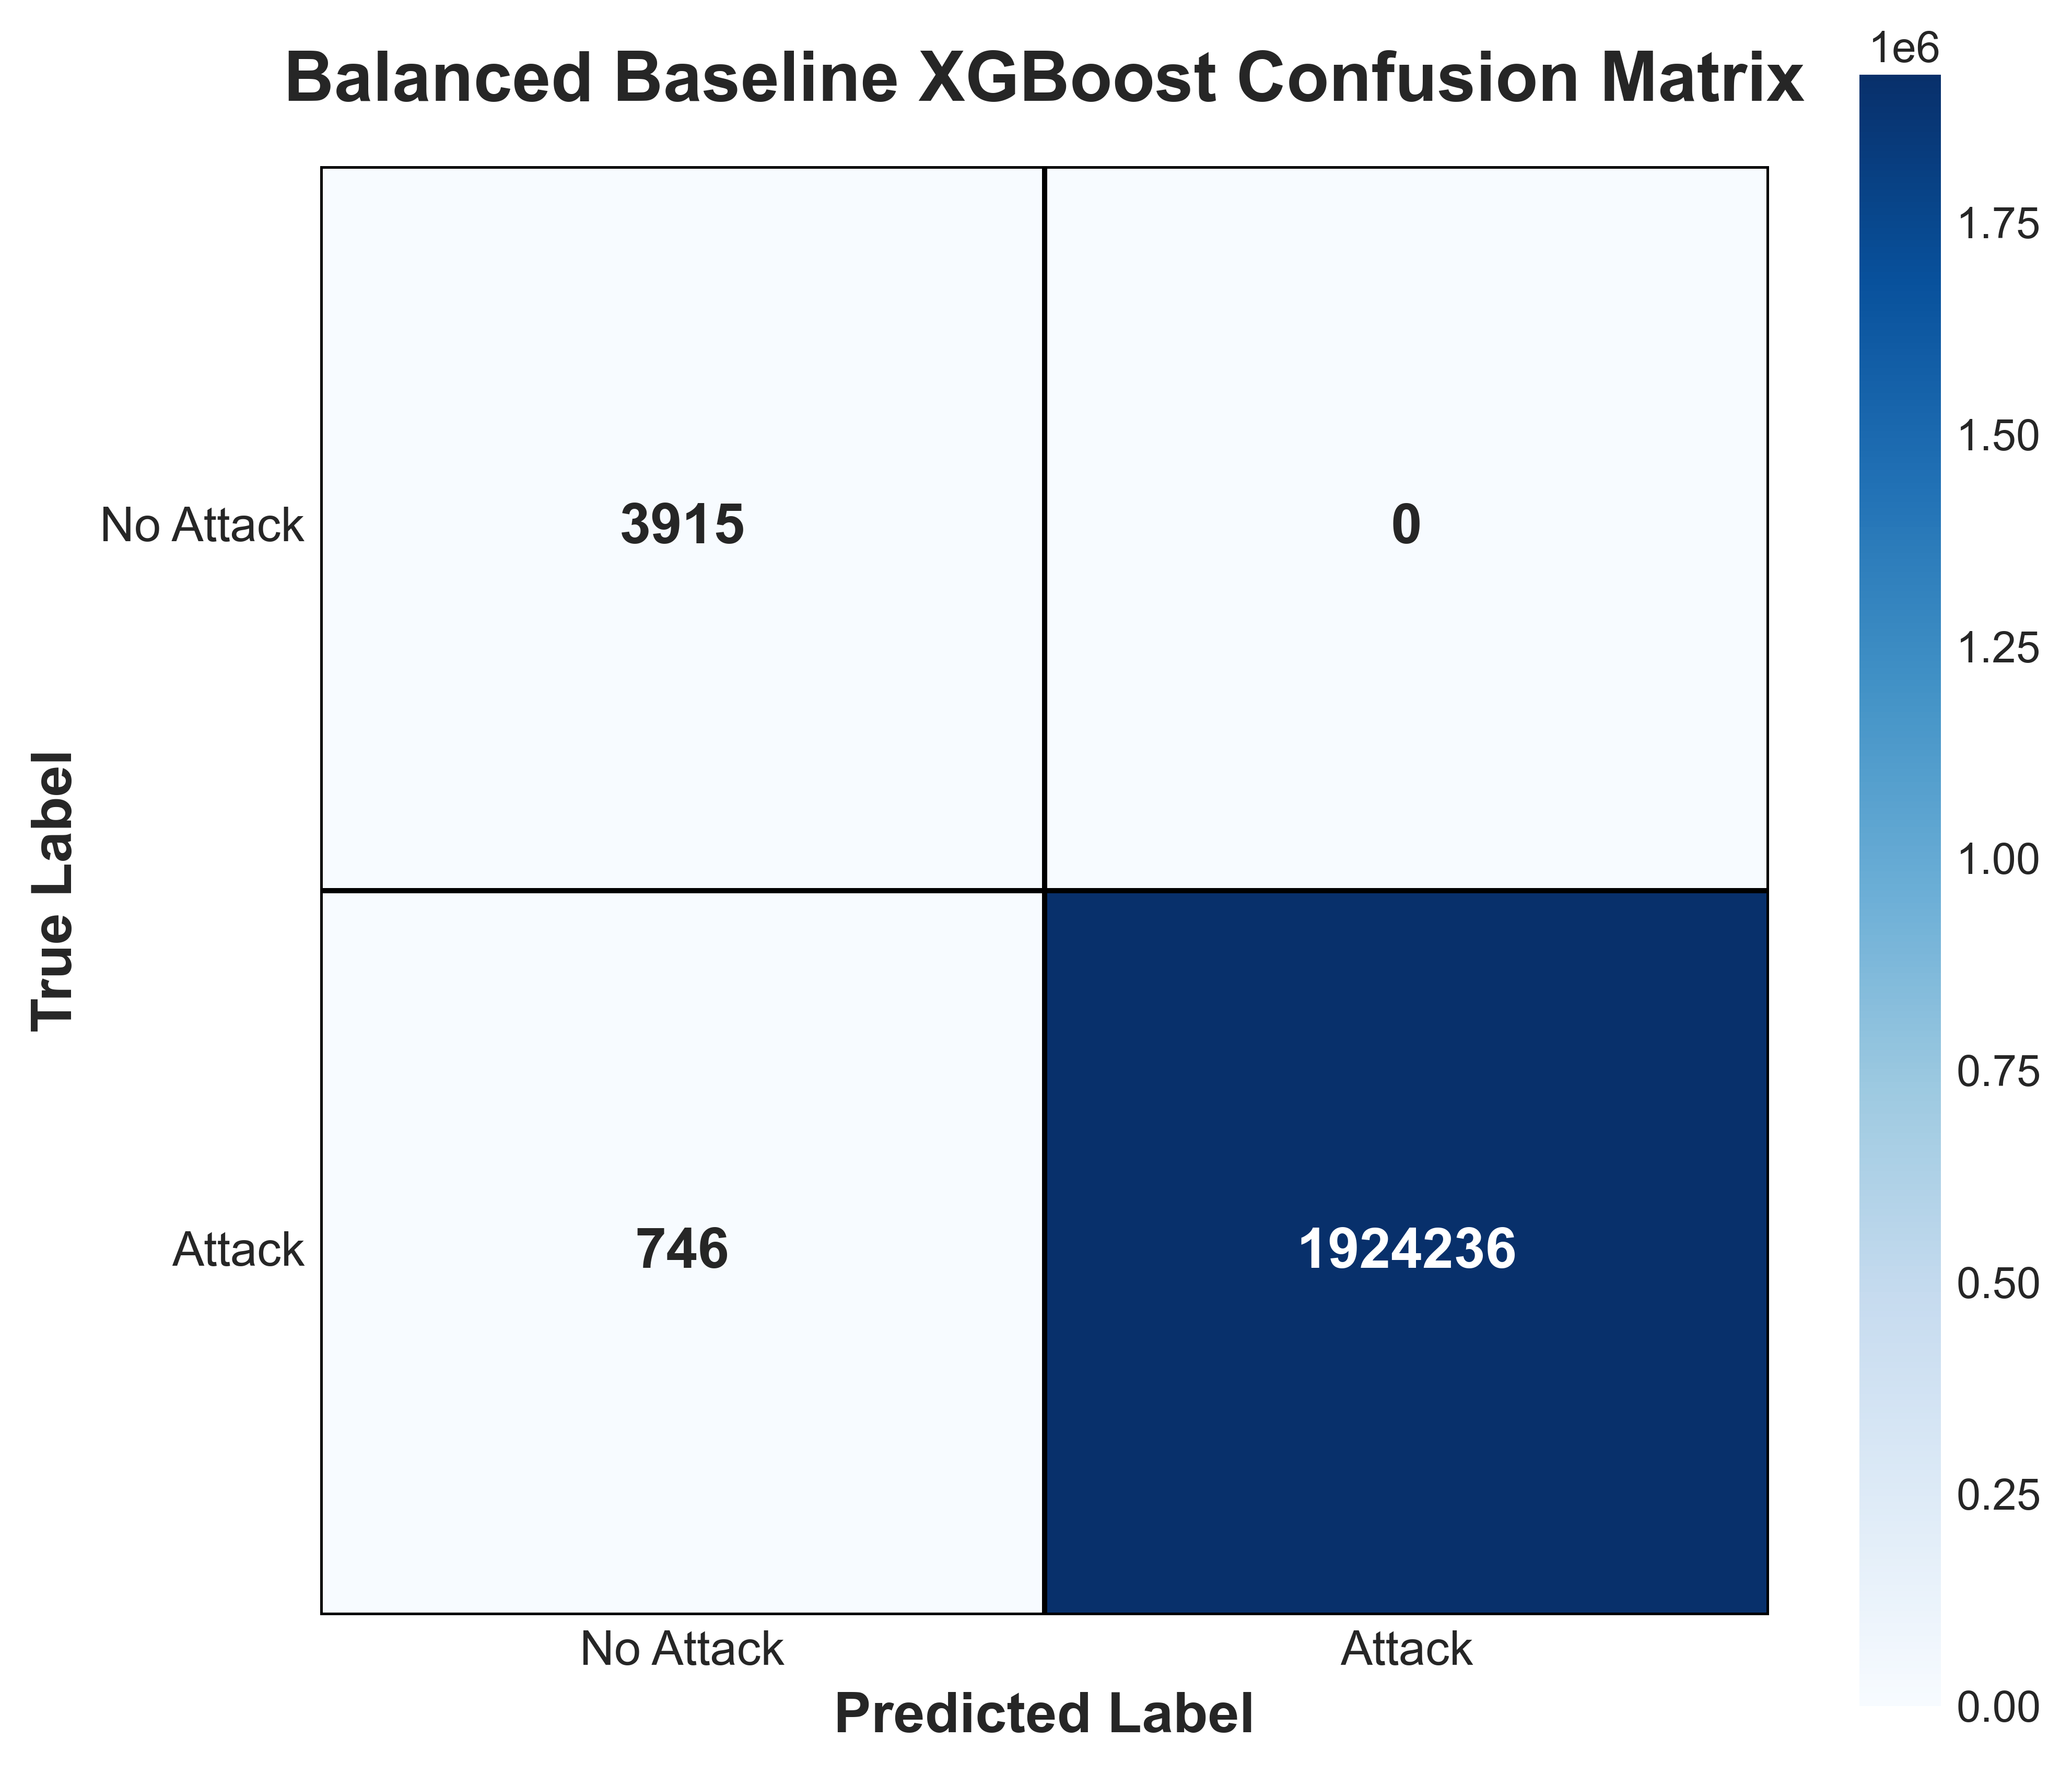

In [21]:
confusion_matrix_heatmap(y_test, y_pred, save_dir="results/balanced", model_name="Balanced Baseline XGBoost",)

# **2. Optuna Optimization**

To improve the performance of the baseline neural network, a multi-objective hyperparameter optimization process was implemented using **Optuna**. Optuna is an automatic hyperparameter optimization framework designed to efficiently explore large search spaces and identify optimal model configurations.

In this project, Optuna was used to optimize the neural network architecture and training parameters while simultaneously considering two objectives:

- Maximize the F1-score
- Minimize prediction time

This approach allows the identification of models that not only achieve high classification performance but also maintain low inference latency for real-time cybersecurity applications.

In [ ]:
#import sys
#!{sys.executable} -m pip install plotly


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
#import sys
#!{sys.executable} -m pip install optuna


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [23]:
import time
import numpy as np
import optuna
import tensorflow as tf

### **Optimization Strategy**

The study was configured as a **multi-objective optimization problem**, where each trial generates a different neural network configuration.

For every trial, Optuna evaluates:

1. Neural network architecture
2. Learning rate
3. Batch size
4. Number of hidden layers
5. Hidden layer dimensions

The resulting model is then trained and evaluated using the validation dataset.

The following hyperparameters were explored during optimization:

| Hyperparameter | Search Range |
|---|---|
| Hidden layer size | 32 → 256 |
| Number of hidden layers | 1 → 5 |
| Learning rate | 1e-5 → 1e-2 |
| Batch size | 32, 64, 128 |



In [24]:
RANDOM_STATE = 42
N_TRIALS = 100
N_RUNS_TIMING = 10

# Number of boosting trees
N_ESTIMATORS_MIN = 50
N_ESTIMATORS_MAX = 300

# Tree depth
MAX_DEPTH_MIN = 3
MAX_DEPTH_MAX = 12

# Learning rate
LEARNING_RATE_MIN = 1e-3
LEARNING_RATE_MAX = 3e-1

# Row sampling
SUBSAMPLE_MIN = 0.5
SUBSAMPLE_MAX = 1.0

# Feature sampling
COLSAMPLE_BYTREE_MIN = 0.5
COLSAMPLE_BYTREE_MAX = 1.0

# Minimum loss reduction for split
GAMMA_MIN = 0.0
GAMMA_MAX = 5.0

# Minimum child weight
MIN_CHILD_WEIGHT_MIN = 1
MIN_CHILD_WEIGHT_MAX = 20

# Optimization directions
DIRECTIONS = ["maximize", "minimize"]

### **Multi-Objective Optimization**

The optimization process simultaneously evaluates:

| Objective | Goal |
|---|---|
| F1-score | Maximize |
| Prediction time | Minimize |

Because these objectives are conflicting, Optuna generates a **Pareto Front**, which contains the set of optimal trade-off solutions.

Some models may achieve:

- Higher classification accuracy with slower inference
- Faster prediction speed with slightly lower performance

This methodology allows selecting models according to system requirements and computational constraints.



In [25]:
from xgboost import XGBClassifier

def build_model(
    n_estimators,
    max_depth,
    learning_rate,
    subsample,
    colsample_bytree,
    gamma,
    min_child_weight
):

    model = XGBClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        gamma=gamma,
        min_child_weight=min_child_weight,
        objective="binary:logistic",
        eval_metric="logloss",
        tree_method="hist",
        n_jobs=-1,
        random_state=RANDOM_STATE
    )

    return model

In [28]:
def train_and_evaluate(model):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    f1 = f1_score(y_val, y_pred)

    return f1

### **Prediction Time Evaluation**

Inference latency was incorporated as a second optimization objective in order to evaluate real-time applicability.

Prediction time was measured multiple times to reduce noise and variability:
The average prediction time across all runs was used during optimization.


In [27]:
import time
import numpy as np

def measure_inference_time(model, X_val, n_runs=N_RUNS_TIMING):
    sample = X_val[:1]
    times = []
    # Warmup
    model.predict(sample)
    for _ in range(n_runs):
        start = time.perf_counter()
        model.predict(sample)
        end = time.perf_counter()
        times.append(end - start)
    return float(np.mean(times))

In [26]:
def objective(trial):

    # Hyperparameters
    n_estimators = trial.suggest_int(
        "n_estimators",
        N_ESTIMATORS_MIN,
        N_ESTIMATORS_MAX
    )

    max_depth = trial.suggest_int(
        "max_depth",
        MAX_DEPTH_MIN,
        MAX_DEPTH_MAX
    )

    learning_rate = trial.suggest_float(
        "learning_rate",
        LEARNING_RATE_MIN,
        LEARNING_RATE_MAX,
        log=True
    )

    subsample = trial.suggest_float(
        "subsample",
        SUBSAMPLE_MIN,
        SUBSAMPLE_MAX
    )

    colsample_bytree = trial.suggest_float(
        "colsample_bytree",
        COLSAMPLE_BYTREE_MIN,
        COLSAMPLE_BYTREE_MAX
    )

    gamma = trial.suggest_float(
        "gamma",
        GAMMA_MIN,
        GAMMA_MAX
    )

    min_child_weight = trial.suggest_int(
        "min_child_weight",
        MIN_CHILD_WEIGHT_MIN,
        MIN_CHILD_WEIGHT_MAX
    )

    # Build model
    model = build_model(
        n_estimators=n_estimators,
        max_depth=max_depth,
        learning_rate=learning_rate,
        subsample=subsample,
        colsample_bytree=colsample_bytree,
        gamma=gamma,
        min_child_weight=min_child_weight
    )

    # Train
    model.fit(X_train, y_train)

    # Validation predictions
    y_pred = model.predict(X_val)

    # F1 score
    f1 = f1_score(y_val, y_pred)

    # Inference time
    inference_time = measure_inference_time(
        model,
        X_val
    )

    # Multi-objective optimization
    return f1, inference_time

In [29]:
def create_study():

    study = optuna.create_study(
        directions=DIRECTIONS,
        sampler=optuna.samplers.NSGAIISampler(seed=RANDOM_STATE)
    )

    return study

### **Pareto Front Analysis**
In this project, the optimization process simultaneously attempts to:

- Maximize the F1-score
- Minimize prediction time

These objectives are inherently conflicting because more complex neural network architectures may achieve higher classification performance while also increasing computational cost and inference latency.
To analyze this trade-off, Optuna generates a **Pareto Front**.

A Pareto Front is the set of optimal solutions in a multi-objective optimization problem.
A solution belongs to the Pareto Front if:

- No other solution improves one objective without worsening the other.
- Its F1-score cannot be improved without increasing prediction time.
- Its prediction time cannot be reduced without decreasing F1-score.

These solutions represent the best trade-offs discovered during optimization.

###  **Pareto Dominance**

A model is said to dominate another model if:

- It achieves equal or better performance in all objectives
- And strictly better performance in at least one objective

The Pareto Front provides multiple optimal candidate models rather than a single “best” solution.

This allows selecting models depending on system requirements.
During Optuna optimization:

- Each trial generates a different neural network architecture.
- Each model is evaluated using:
  - F1-score
  - Prediction time

After all trials are completed, Optuna identifies the subset of non-dominated solutions.

These solutions form the Pareto Front.

The Pareto-optimal models represent the best balance between:

- Detection capability
- Computational efficiency

In [30]:
def print_pareto_front(study):

    pareto_trials = study.best_trials
    print(f"\nPareto-front trials: {len(pareto_trials)}")
    print("=" * 60)
    for t in pareto_trials:

        f1_score_val = t.values[0]
        inf_time_ms = t.values[1] * 1000
        print(
            f"Trial #{t.number:<3} | "
            f"F1-score: {f1_score_val:.4f} | "
            f"Inference Time: {inf_time_ms:.3f} ms"
        )
        print(f"Parameters: {t.params}")
        print("-" * 60)

In [31]:
def plot_pareto_front(study, save_path="pareto_balance"):
    if save_path not in os.listdir("results/balanced"):
        os.makedirs(save_path, exist_ok=True)
    pareto_trials = study.best_trials

    f1_scores = [t.values[0] for t in pareto_trials]

    inference_times = [
        t.values[1] * 1000
        for t in pareto_trials
    ]

    plt.figure(figsize=(7, 5), dpi=300)

    plt.scatter(
        inference_times,
        f1_scores,
        s=80,
        alpha=0.8
    )

    # Annotate each point with trial number
    for i, t in enumerate(pareto_trials):

        plt.annotate(
            f"T{t.number}",
            (inference_times[i], f1_scores[i]),
            textcoords="offset points",
            xytext=(5, 5),
            fontsize=9
        )

    plt.xlabel("Inference Time (ms)", fontsize=12)
    plt.ylabel("F1-score", fontsize=12)

    plt.title(
        "Pareto Front for Multi-Objective Optimization",
        fontsize=14,
        weight='bold'
    )

    plt.grid(True)

    plt.tight_layout()

    # Save publication-quality figure
    if save_path:
        plt.savefig(
            save_path,
            dpi=300,
            bbox_inches='tight'
        )

    plt.show()

### **Training Workflow**
Unlike the baseline model, the Optuna architecture is not fixed.
The number of layers and neurons is dynamically generated according to the sampled hyperparameters.
This allows the optimizer to explore multiple architectural combinations and identify efficient configurations.

For each Optuna trial:

1. A neural network architecture is generated dynamically.
2. Hyperparameters are sampled from the search space.
3. The model is trained using the balanced training dataset.
4. Validation metrics are computed.
5. Prediction time is measured multiple times.
6. Both objectives are returned to the optimizer.

The optimization process continues for a total of 100 trials.




In [32]:
study = create_study()

[I 2026-05-31 02:44:30,751] A new study created in memory with name: no-name-8ca7c327-5ab8-472e-9f2b-92e1dcf8fca1


In [33]:
study.optimize(objective, n_trials=50)

[I 2026-05-31 02:44:32,352] Trial 0 finished with values: [0.9995208433157643, 0.0006574399999863089] and parameters: {'n_estimators': 144, 'max_depth': 12, 'learning_rate': 0.06504856968981275, 'subsample': 0.7993292420985183, 'colsample_bytree': 0.5780093202212182, 'gamma': 0.7799726016810132, 'min_child_weight': 2}.
[I 2026-05-31 02:44:32,657] Trial 1 finished with values: [0.9992014055262738, 0.0004166399999803616] and parameters: {'n_estimators': 267, 'max_depth': 9, 'learning_rate': 0.05675206026988748, 'subsample': 0.5102922471479012, 'colsample_bytree': 0.9849549260809971, 'gamma': 4.162213204002109, 'min_child_weight': 5}.
[I 2026-05-31 02:44:32,802] Trial 2 finished with values: [0.9937449879711308, 0.0005735200000344775] and parameters: {'n_estimators': 95, 'max_depth': 4, 'learning_rate': 0.005670807781371429, 'subsample': 0.762378215816119, 'colsample_bytree': 0.7159725093210578, 'gamma': 1.4561457009902097, 'min_child_weight': 13}.
[I 2026-05-31 02:44:32,948] Trial 3 fini

In [34]:
print_pareto_front(study)


Pareto-front trials: 5
Trial #1   | F1-score: 0.9992 | Inference Time: 0.417 ms
Parameters: {'n_estimators': 267, 'max_depth': 9, 'learning_rate': 0.05675206026988748, 'subsample': 0.5102922471479012, 'colsample_bytree': 0.9849549260809971, 'gamma': 4.162213204002109, 'min_child_weight': 5}
------------------------------------------------------------
Trial #6   | F1-score: 0.9984 | Inference Time: 0.392 ms
Parameters: {'n_estimators': 58, 'max_depth': 12, 'learning_rate': 0.004375517173207359, 'subsample': 0.831261142176991, 'colsample_bytree': 0.6558555380447055, 'gamma': 2.600340105889054, 'min_child_weight': 11}
------------------------------------------------------------
Trial #28  | F1-score: 0.9995 | Inference Time: 0.442 ms
Parameters: {'n_estimators': 232, 'max_depth': 11, 'learning_rate': 0.1575508085526967, 'subsample': 0.8899377729288119, 'colsample_bytree': 0.8210158230771438, 'gamma': 0.42069982497524416, 'min_child_weight': 4}
--------------------------------------------

In cybersecurity systems, achieving high classification accuracy is important, but inference speed is also critical.

A highly accurate model may become impractical if:

- Prediction latency is too high
- Real-time detection is required
- Computational resources are limited

The Pareto Front analysis allows selecting architectures that satisfy operational constraints while maintaining strong detection performance.

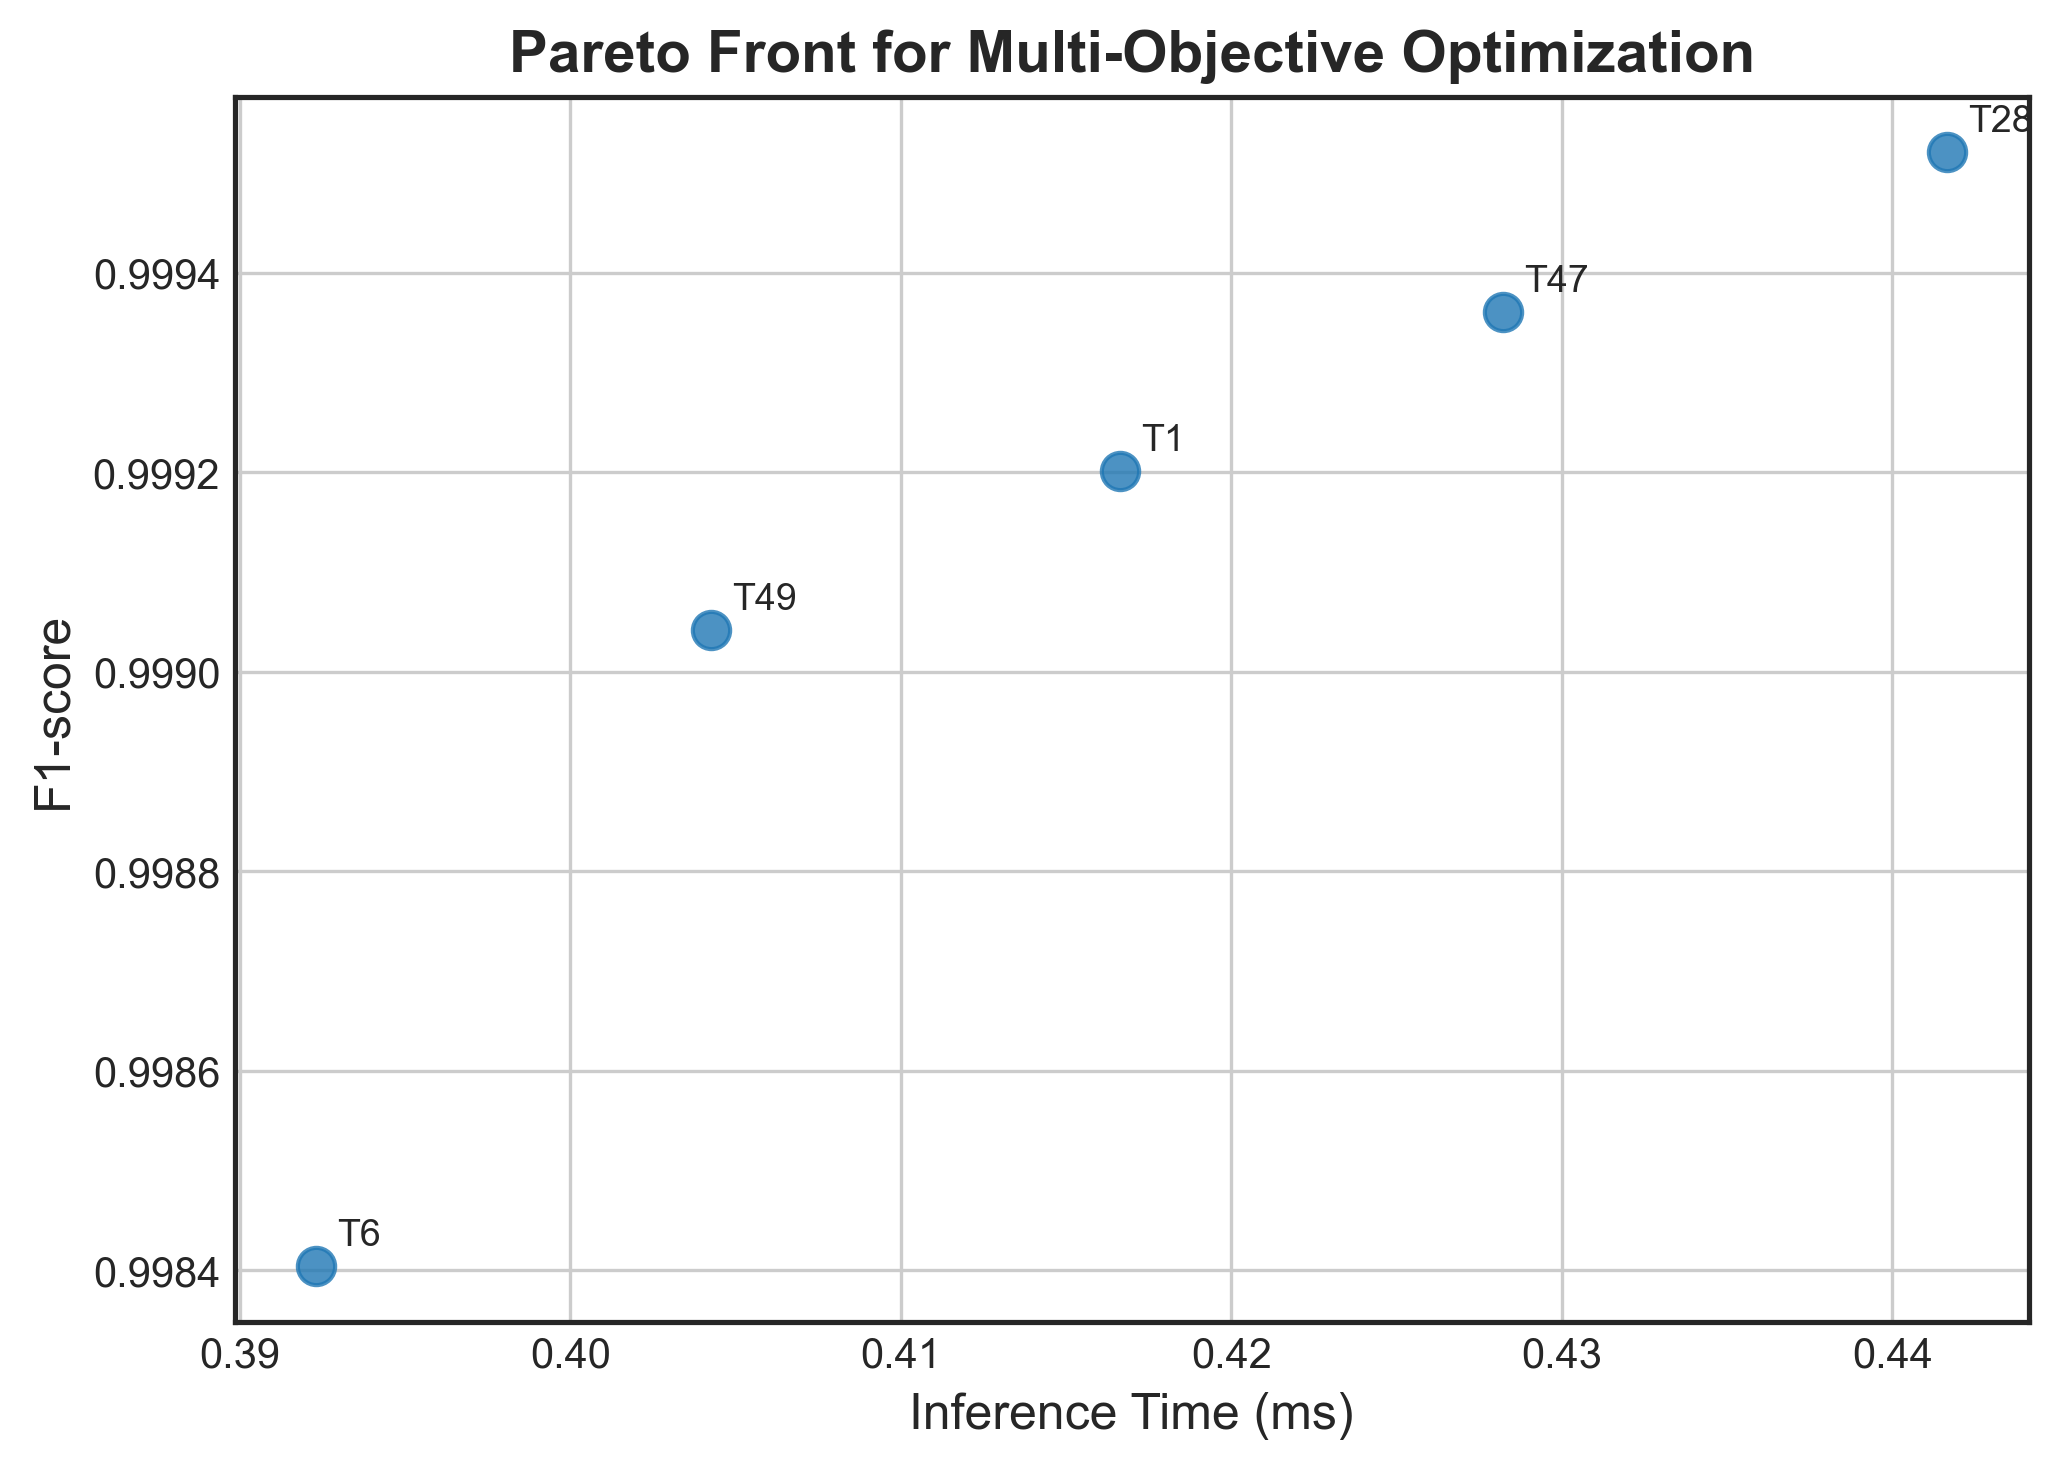

In [35]:
plot_pareto_front(study)

In [38]:
def pareto_dataframe(study):

    rows = []

    for t in study.best_trials:

        rows.append({
            "Trial": t.number,
            "F1-score": round(t.values[0], 4),
            "Inference Time (ms)": round(t.values[1] * 1000, 3),
            "n_estimators": t.params["n_estimators"],
            "max_depth": t.params["max_depth"],
            "learning_rate": round(t.params["learning_rate"], 6),
            "subsample": round(t.params["subsample"], 4),
            "colsample_bytree": round(t.params["colsample_bytree"], 4),
            "gamma": round(t.params["gamma"], 4),
            "min_child_weight": t.params["min_child_weight"]
        })

    df = pd.DataFrame(rows)

    return df

In [39]:
df_pareto = pareto_dataframe(study)

print(df_pareto)

   Trial  F1-score  Inference Time (ms)  n_estimators  max_depth  \
0      1    0.9992                0.417           267          9   
1      6    0.9984                0.392            58         12   
2     28    0.9995                0.442           232         11   
3     47    0.9994                0.428           112          6   
4     49    0.9990                0.404           158          6   

   learning_rate  subsample  colsample_bytree   gamma  min_child_weight  
0       0.056752     0.5103            0.9850  4.1622                 5  
1       0.004376     0.8313            0.6559  2.6003                11  
2       0.157551     0.8899            0.8210  0.4207                 4  
3       0.075384     0.5072            0.5580  0.2300                 1  
4       0.033538     0.8175            0.5227  1.8731                13  


In [40]:
df_pareto.to_csv("pareto_balanced_results.csv", index=False)

In [41]:
best_trial = df_pareto.iloc[0]

# **4.Train Best Model**

In [43]:
best_params = best_trial

final_model = build_model(
    n_estimators=int(best_params["n_estimators"]),
    max_depth=int(best_params["max_depth"]),
    learning_rate=float(best_params["learning_rate"]),
    subsample=float(best_params["subsample"]),
    colsample_bytree=float(best_params["colsample_bytree"]),
    gamma=float(best_params["gamma"]),
    min_child_weight=int(best_params["min_child_weight"])
)

final_model.fit(
    X_train,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.985, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=4.1622,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.056752,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=9, max_leaves=None,
              min_child_weight=5, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=267, n_jobs=-1,
              num_parallel_tree=None, ...)

In [44]:
# Predictions
y_pred = final_model.predict(X_test)

# F1-score
test_f1 = f1_score(y_test, y_pred)

# Measure single-sample latency
sample = X_test[:1]

times = []

# Warmup
final_model.predict(sample)

for _ in range(100):
    start = time.perf_counter()
    final_model.predict(sample)
    end = time.perf_counter()
    times.append(end - start)

# Average latency in milliseconds
avg_inference_time_ms = np.mean(times) * 1000

# Results
print(f"Test F1-score: {test_f1:.4f}")

print(
    f"Average Inference Time: "
    f"{avg_inference_time_ms:.4f} ms/sample"
)

Test F1-score: 0.9997
Average Inference Time: 0.6389 ms/sample


### **Metrics**

In [45]:
y_pred = final_model.predict(X_test)

y_prob = final_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.9994343917793433
Precision: 0.9999994802205736
Recall: 0.9994337609390633
F1 Score: 0.9997165405475626
AUC: 0.9999500170145061

Confusion Matrix:
[[   3914       1]
 [   1090 1923892]]

Classification Report:
              precision    recall  f1-score   support

           0       0.78      1.00      0.88      3915
           1       1.00      1.00      1.00   1924982

    accuracy                           1.00   1928897
   macro avg       0.89      1.00      0.94   1928897
weighted avg       1.00      1.00      1.00   1928897



Confusion matrix saved to:
 - results\plots\optuna_optimization_xgboost_confusion_matrix.png
 - results\plots\optuna_optimization_xgboost_confusion_matrix.pdf


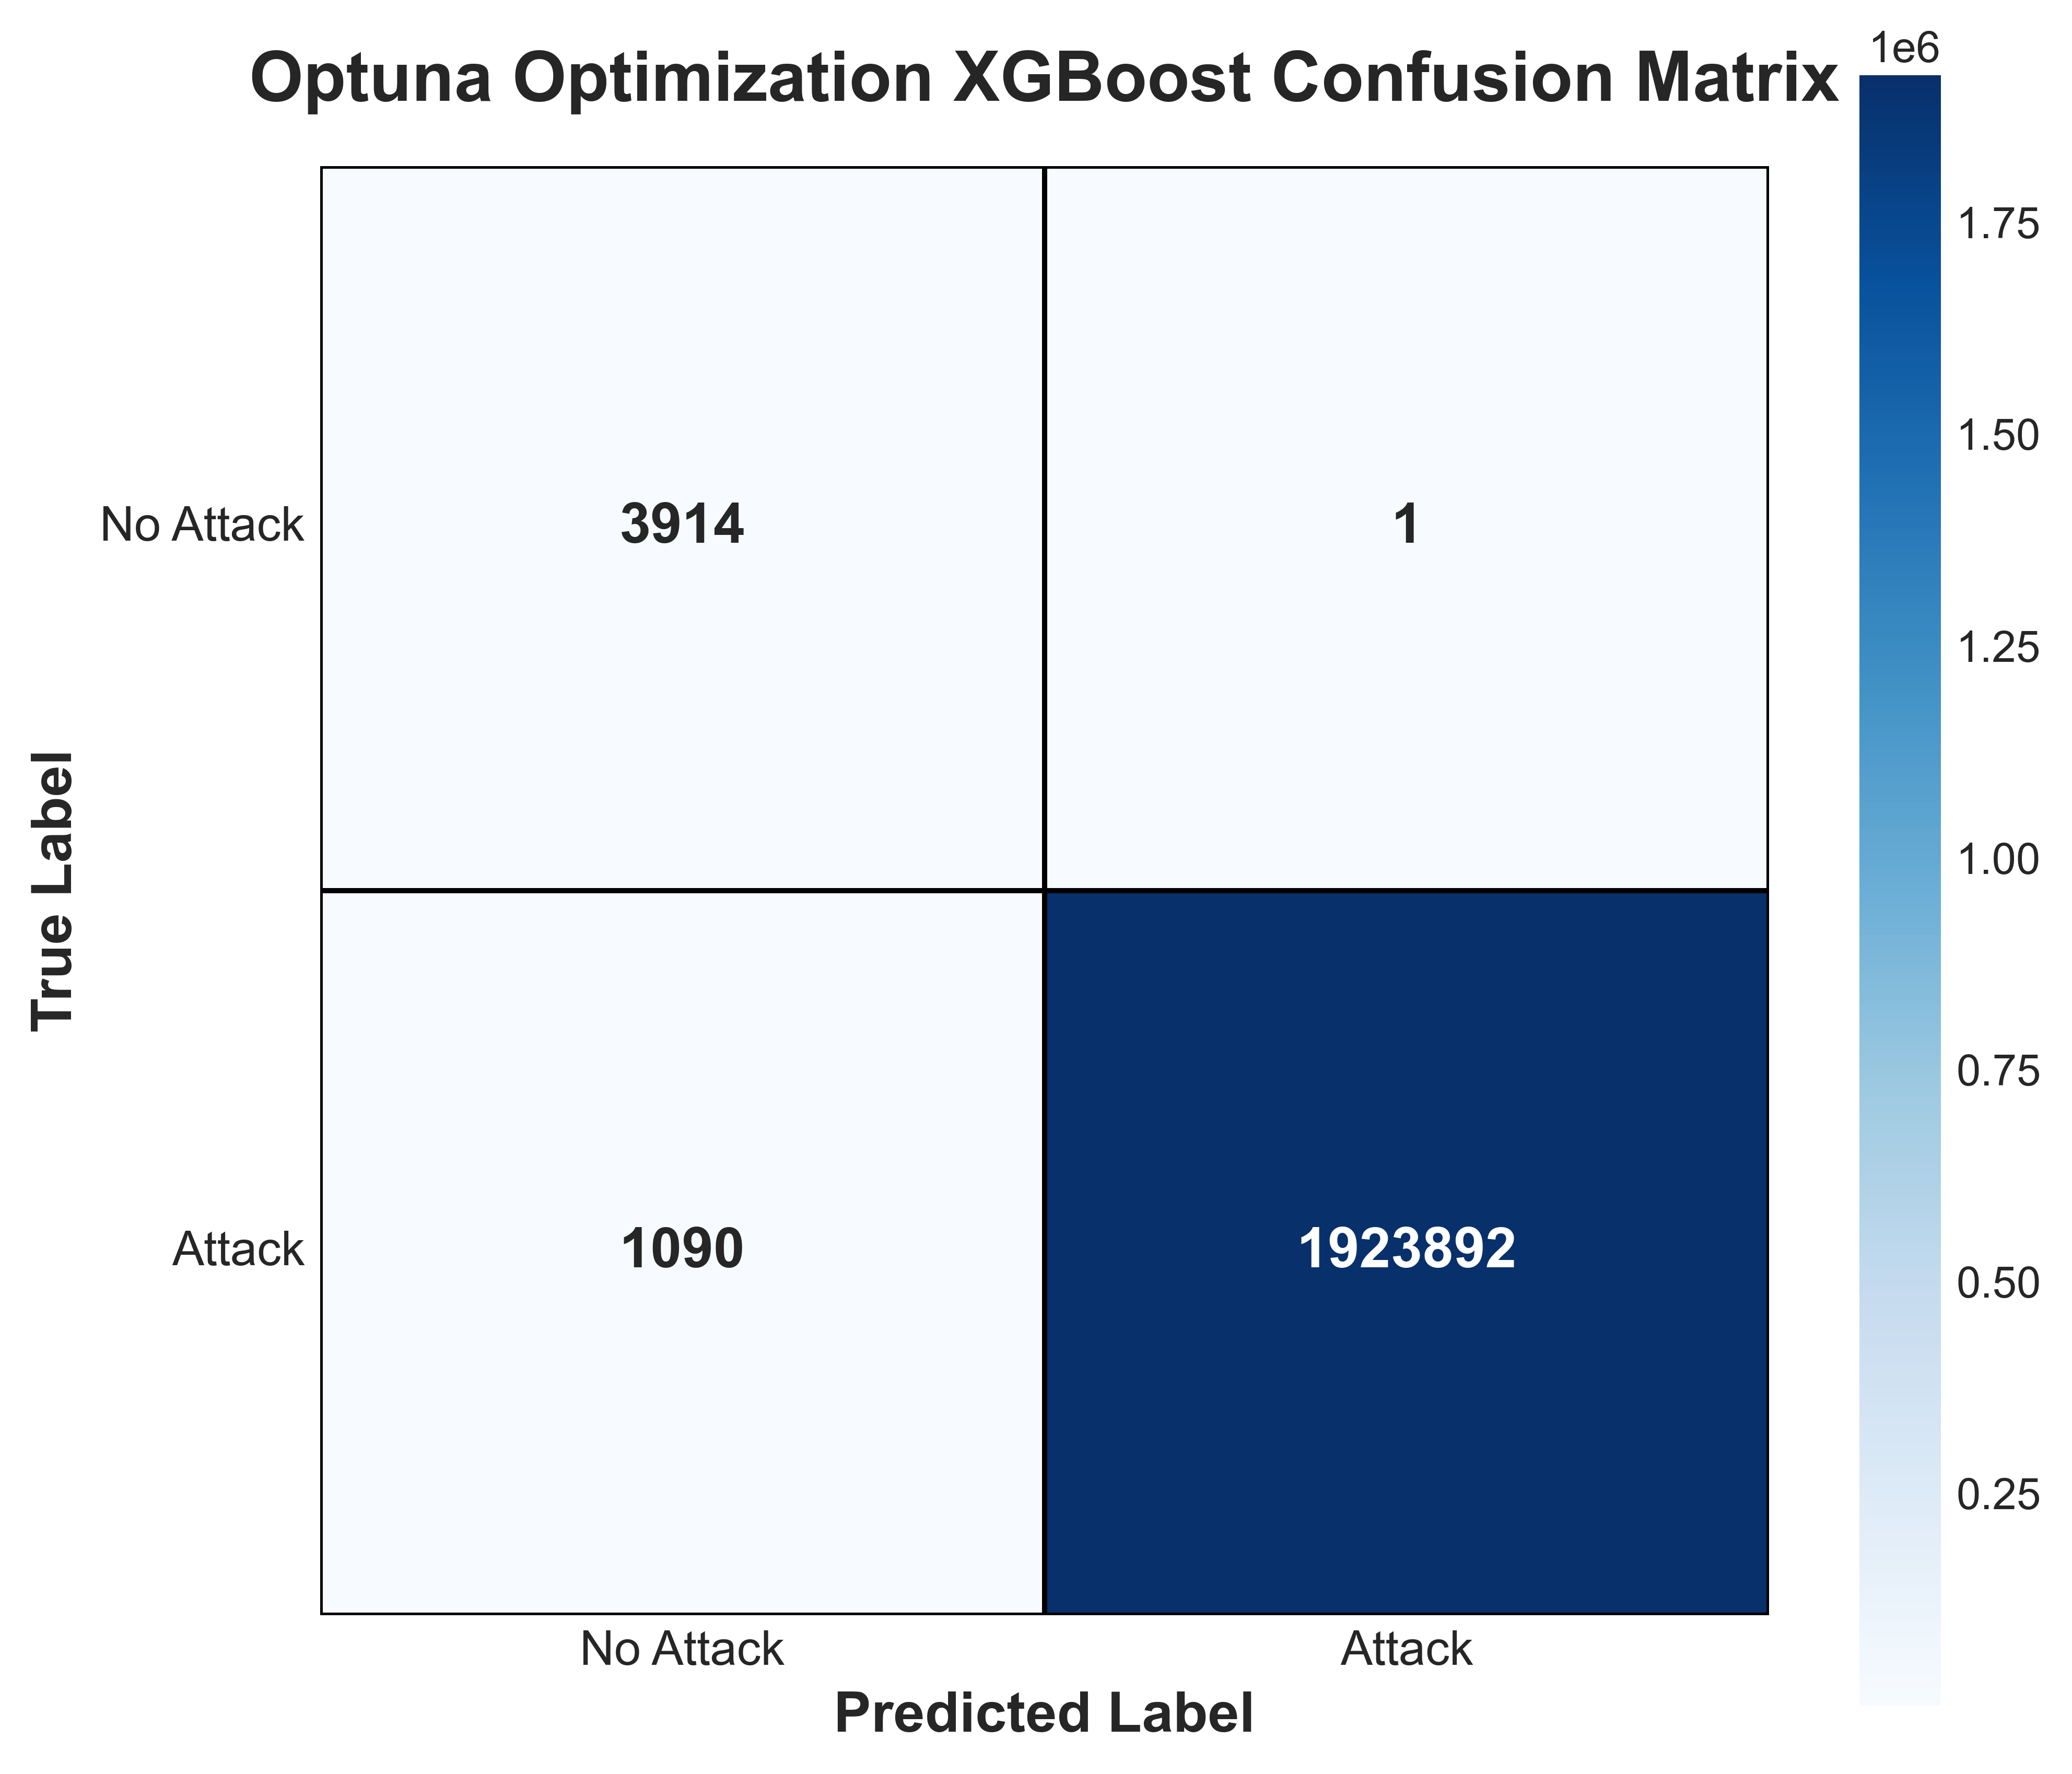

In [46]:
confusion_matrix_heatmap(y_test, y_pred, save_dir="results/plots", model_name="Optuna Optimization XGBoost", normalize=False)

In [47]:
from sklearn.metrics import roc_auc_score

results = {

    "accuracy": float(
        accuracy_score(y_test, y_pred)
    ),

    "precision": float(
        precision_score(y_test, y_pred)
    ),

    "recall": float(
        recall_score(y_test, y_pred)
    ),

    "f1_score": float(
        f1_score(y_test, y_pred)
    ),

    "auc": float(
        roc_auc_score(
            y_test,
            y_prob
        )
    ),

    "inference_time_ms": float(
        avg_inference_time_ms
    ),

    "confusion_matrix": confusion_matrix(
        y_test,
        y_pred
    ).tolist(),

    "classification_report": classification_report(
        y_test,
        y_pred,
        output_dict=True
    )
}

### **Export results in json format**

In [48]:
os.makedirs("results/balanced", exist_ok=True)

results_path = os.path.join(
    "results/balanced",
    "evaluation_results_balanced_optuna.json"
)

with open(results_path, "w") as f:
    json.dump(
        results,
        f,
        indent=4
    )

print(f"Results exported to: {results_path}")

Results exported to: results/balanced\evaluation_results_balanced_optuna.json
